In [2]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import sem
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
import netCDF4
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops, process_abiotic_data, site_sample_area
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot, abiotic_plot

In [3]:
abiotic_data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola/abiotic_data/'
start_date = '2022-08-01T00:00:00'
end_date = '2023-03-31T00:00:00'
data, seven_day_averages_data, daily_averages_data = process_abiotic_data(abiotic_data_path, start_date, end_date)

Available datasets:
- hobo
- star_oddi
- fort_point_daily
- fort_point_hourly
- precipitation

Available 7-day average datasets:
- hobo_seven_day_average
- star_oddi_seven_day_average
- fort_point_daily_seven_day_average
- fort_point_hourly_seven_day_average
- precipitation_seven_day_average

Available daily average datasets:
- hobo_daily_average
- star_oddi_daily_average
- fort_point_daily_daily_average
- fort_point_hourly_daily_average
- precipitation_daily_average


In [4]:
# Accessing the datasets
hobo_data = data['hobo']
star_oddi_data = data['star_oddi']
fort_point_daily_data = data['fort_point_daily']
fort_point_hourly_data = data['fort_point_hourly']
precipitation_data = data['precipitation']

hobo_seven_day_average_data = seven_day_averages_data['hobo_seven_day_average']
star_oddi_seven_day_average_data = seven_day_averages_data['star_oddi_seven_day_average']
fort_point_seven_day_average_data = seven_day_averages_data['fort_point_daily_seven_day_average']
fort_point_seven_day_hourly_average_data = seven_day_averages_data['fort_point_hourly_seven_day_average']
precipitation_seven_day_average_data = seven_day_averages_data['precipitation_seven_day_average']

hobo_average_data = daily_averages_data['hobo_daily_average']
star_oddi_average_data = daily_averages_data['star_oddi_daily_average']
fort_point_daily_average_data = daily_averages_data['fort_point_daily_daily_average']
fort_point_hourly_average_data = daily_averages_data['fort_point_hourly_daily_average']
precipitation_average_data = daily_averages_data['precipitation_daily_average']

## Making variables to hold the URL's we are pointing at

---



In [5]:
mur_anom_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anom1day'
mur_sst_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41'

mur_anom_month_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anommday'
mur_sst_month__url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday'

# In case someone wants to look at upwelling data
upwell_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdQBstress3day_LonPM180'
#https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo_LonPM180.html

## Open a pointer to open the dataset

* These new variables will hold all the data for that link
* We'll run one below so you can see what it looks like
---

In [7]:
#sst_anom = xr.open_dataset(mur_anom_url)
sst = xr.open_dataset(mur_sst_url)

month_sst_anom = xr.open_dataset(mur_anom_month_url)
month_sst = xr.open_dataset(mur_sst_month__url)

## Running sst variable

Returns the metadata which lets you know the dimensions and coordinates:
* Number of time values and range
* Latitude and Longitude values and range

Also shows the variables are in this dataset:
* analysed sst
* analysis error
* mast
* sea ice fraction

---

In [8]:
sst

<xarray.Dataset>
Dimensions:           (time: 8266, latitude: 17999, longitude: 36000)
Coordinates:
  * time              (time) datetime64[ns] 2002-06-01T09:00:00 ... 2025-01-1...
  * latitude          (latitude) float32 -89.99 -89.98 -89.97 ... 89.98 89.99
  * longitude         (longitude) float32 -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, latitude, longitude) float64 ...
    analysis_error    (time, latitude, longitude) float64 ...
    mask              (time, latitude, longitude) float32 ...
    sea_ice_fraction  (time, latitude, longitude) float64 ...
Attributes: (12/51)
    _NCProperties:              version=2,netcdf=4.7.4,hdf5=1.8.12
    acknowledgement:            Please acknowledge the use of these data with...
    cdm_data_type:              Grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    Conventions:                CF-1.6, COARDS, ACDD-1.3
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    ...                         ...
    summary:                    This is a merged, multi-sensor L4 Foundation ...
    testOutOfDate:              now-3days
    time_coverage_end:          2025-01-18T09:00:00Z
    time_coverage_start:        2002-06-01T09:00:00Z
    title:                      Multi-scale Ultra-high Resolution (MUR) SST A...
    Westernmost_Easting:        -179.99

# Creating a small square area for satellite data to retrieve from, offshore about 5km

In [9]:
start_time = '2022-08-27T12:00:00'
end_time = '2023-04-22T12:00:00'
data = sst

ap_beach = site_sample_area(data=data, start_time=start_time, end_time=end_time,site='ap')

lon: -122.580725 -122.54072500000001
lat: 37.527919000000004 37.567919


# Visualize SST from data loggers and satellite data

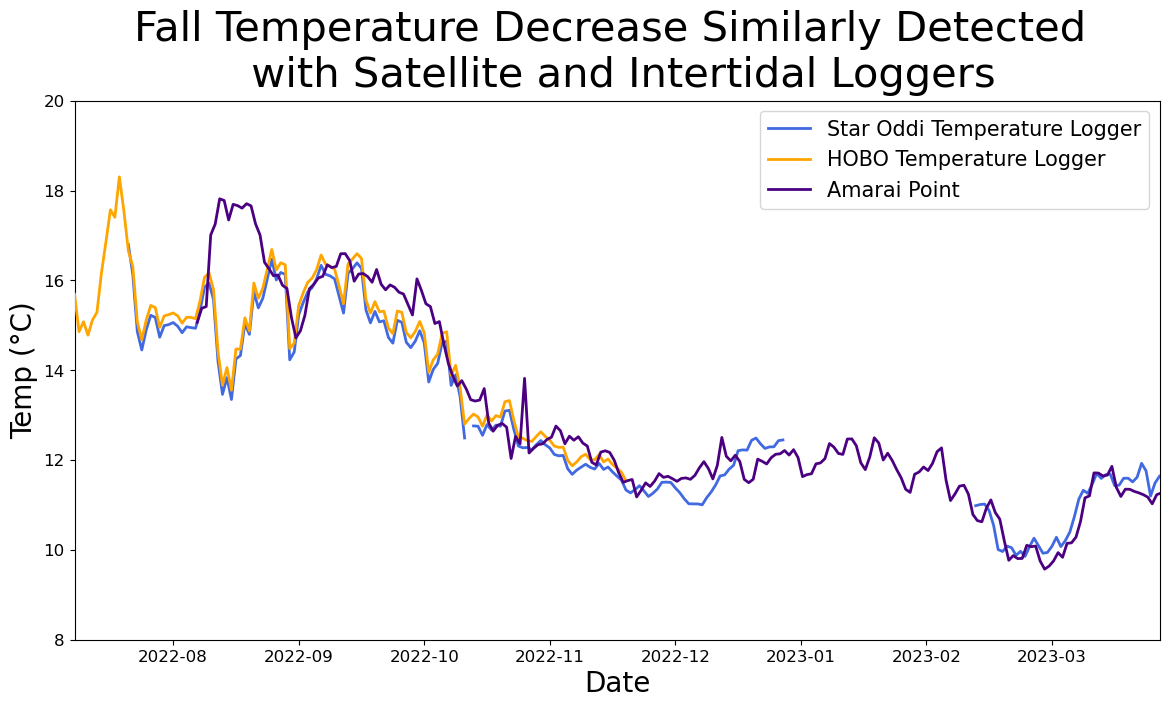

In [13]:
data_dict = {
    'Star Oddi Temperature Logger': (star_oddi_average_data['date_time'], star_oddi_average_data['temp_c_daily_average'], 'royalblue', 'line'),
    'HOBO Temperature Logger': (hobo_average_data['date_time'], hobo_average_data['temp_c_daily_average'], 'orange', 'line'),
    'Amarai Point': (ap_beach.time, ap_beach.mean(axis=(1,2)), 'indigo', 'line')
}

abiotic_plot('line', data_dict, 
            'Fall Temperature Decrease Similarly Detected \n with Satellite and Intertidal Loggers', 
            'Date', 'Temp (°C)', 
            (start_date, end_date), 
            ylim=(8, 20), 
            save_path='figures/temperature_trends.png')


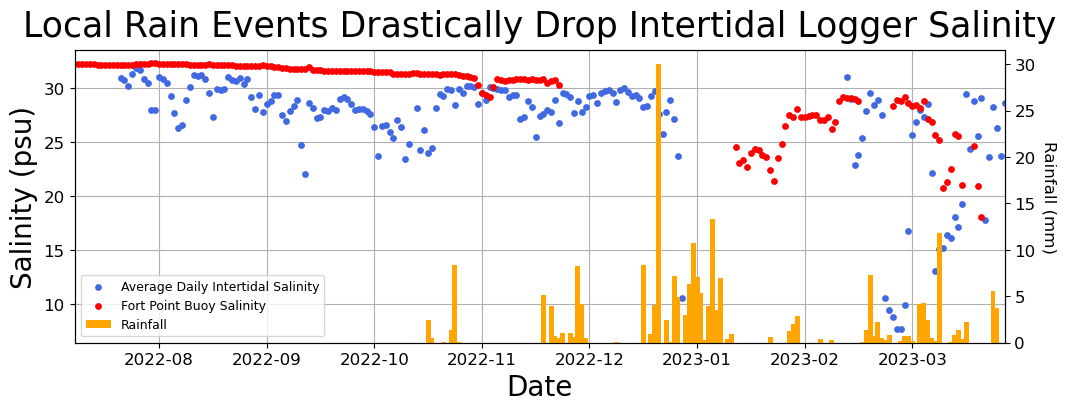

In [12]:
data_dict = {
    'Average Daily Intertidal Salinity': (star_oddi_average_data['date_time'], star_oddi_average_data['salinity_ppt_daily_average'], 'royalblue', 'scatter'),
    'Fort Point Buoy Salinity': (fort_point_daily_average_data['date_time'], fort_point_daily_average_data['salinity_ppt_daily_average'], 'red', 'scatter'),
    'rain': (precipitation_data['date_time'], precipitation_data['rain_mm'], 'orange', 'bar')
}

abiotic_plot('scatter', data_dict, 
            'Local Rain Events Drastically Drop Intertidal Logger Salinity', 
            'Date', 'Salinity (psu)', 
            (start_date, end_date), 
            save_path='figures/salinity_rainfall.png')